In [1]:
# ============================================================
# Training-only univariate t-test CpG screening + ridge model
# Case/control and cycle phase
# ============================================================

In [31]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from kneed import KneeLocator

In [18]:
out_dir = "/mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs"
os.makedirs(out_dir, exist_ok=True)

cc_out_dir = os.path.join(out_dir, "case_control")
cp_out_dir = os.path.join(out_dir, "cycle_phase")

os.makedirs(cc_out_dir, exist_ok=True)
os.makedirs(cp_out_dir, exist_ok=True)

print("Main output directory:", out_dir)
print("Case/control output directory:", cc_out_dir)
print("Cycle phase output directory:", cp_out_dir)

Main output directory: /mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs
Case/control output directory: /mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/case_control
Cycle phase output directory: /mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/cycle_phase


In [19]:
adata = sc.read_h5ad(
    "/mnt/efs/home/ubuntu/M_smartsva_corrected_with_SH_annot_filtered.h5ad"
)

print(adata)
print(adata.obs.columns.tolist())

AnnData object with n_obs × n_vars = 984 × 759345
    obs: 'sample-id', 'endo', 'endo-stage', 'endo-stage-grouped', 'cycle-phase', 'cycle-phase-source'
['sample-id', 'endo', 'endo-stage', 'endo-stage-grouped', 'cycle-phase', 'cycle-phase-source']


In [20]:
def to_dense(X):
    if sp.issparse(X):
        return X.toarray()
    return np.asarray(X)

In [21]:
def run_ttest_screening(X_train, y_train, feature_names, out_csv=None):
    """
    Runs per-CpG two-sample t-tests using training data only.
    Assumes y_train is binary: 0 vs 1.
    """

    group0 = X_train[y_train == 0]
    group1 = X_train[y_train == 1]

    print("Group 0 shape:", group0.shape)
    print("Group 1 shape:", group1.shape)

    t_stats, p_values = ttest_ind(
        group1,
        group0,
        axis=0,
        equal_var=False,
        nan_policy="omit"
    )

    mean_group0 = np.nanmean(group0, axis=0)
    mean_group1 = np.nanmean(group1, axis=0)

    mean_diff = mean_group1 - mean_group0
    abs_mean_diff = np.abs(mean_diff)

    results_df = pd.DataFrame({
        "CpG": feature_names,
        "t_stat": t_stats,
        "p_value": p_values,
        "neg_log10_p": -np.log10(np.clip(p_values, 1e-300, None)),
        "mean_group0": mean_group0,
        "mean_group1": mean_group1,
        "mean_diff_group1_minus_group0": mean_diff,
        "abs_mean_diff": abs_mean_diff
    })

    results_df = results_df.sort_values(
        "p_value",
        ascending=True,
        na_position="last"
    ).reset_index(drop=True)

    if out_csv is not None:
        results_df.to_csv(out_csv, index=False)
        print("Saved ranked CpGs to:", out_csv)

    return results_df

In [22]:
def select_cpgs_by_elbow(
    ranked_df,
    out_dir,
    label,
    min_features=100,
    max_features=5000
):
    """
    Selects CpGs using elbow on ranked -log10(p-values).
    """

    values = ranked_df["neg_log10_p"].replace([np.inf, -np.inf], np.nan).dropna().values

    x = np.arange(1, len(values) + 1)
    y = values

    kneedle = KneeLocator(
        x,
        y,
        curve="convex",
        direction="decreasing"
    )

    elbow_idx = kneedle.knee

    if elbow_idx is None:
        print("No elbow detected. Falling back to 1000 CpGs.")
        elbow_idx = 1000

    final_n = max(min(elbow_idx, max_features), min_features)

    selected_cpgs = ranked_df["CpG"].iloc[:final_n].tolist()

    plot_path = os.path.join(out_dir, f"{label}_ttest_elbow_plot.png")

    plt.figure(figsize=(7, 5))
    plt.plot(x, y)
    plt.axvline(final_n, linestyle="--", label=f"Selected CpGs = {final_n}")
    plt.xlabel("CpG rank")
    plt.ylabel("-log10(p-value)")
    plt.title(f"{label}: T-test CpG Ranking Elbow")
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_path, dpi=300)
    plt.show()

    selected_path = os.path.join(
        out_dir,
        f"{label}_ttest_elbow_selected_cpgs.csv"
    )

    pd.Series(selected_cpgs, name="CpG").to_csv(selected_path, index=False)

    print("Raw elbow index:", elbow_idx)
    print("Final selected CpGs after bounds:", final_n)
    print("Saved selected CpGs to:", selected_path)
    print("Saved elbow plot to:", plot_path)

    return selected_cpgs, final_n

In [23]:
def evaluate_binary_model(model, X_test, y_test, out_prefix, plot_title):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        "AUROC": roc_auc_score(y_test, y_prob),
        "AUPRC": average_precision_score(y_test, y_prob),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0)
    }

    metrics_df = pd.DataFrame([metrics])
    metrics_path = f"{out_prefix}_metrics.csv"
    metrics_df.to_csv(metrics_path, index=False)

    print("Saved metrics to:", metrics_path)
    display(metrics_df)

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"AUROC = {metrics['AUROC']:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{plot_title}: ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{out_prefix}_roc_curve.png", dpi=300)
    plt.show()

    # PR curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)

    plt.figure(figsize=(6, 6))
    plt.plot(recall_vals, precision_vals, label=f"AUPRC = {metrics['AUPRC']:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{plot_title}: Precision-Recall Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{out_prefix}_pr_curve.png", dpi=300)
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    disp.plot()
    plt.title(f"{plot_title}: Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"{out_prefix}_confusion_matrix.png", dpi=300)
    plt.show()

    return metrics_df

### Prepare Case vs control

In [24]:
adata_cc = adata[adata.obs["endo"].notna()].copy()

print(adata_cc.obs["endo"].value_counts(dropna=False))

endo
1    637
0    347
Name: count, dtype: Int64


In [25]:
y_cc_series = adata_cc.obs["endo"].map({
    "No": 0,
    "Yes": 1,
    "Control": 0,
    "Case": 1,
    0: 0,
    1: 1
})

valid_mask = y_cc_series.notna()

adata_cc = adata_cc[valid_mask].copy()
y_cc = y_cc_series[valid_mask].astype(int).values

X_cc = to_dense(adata_cc.X)
feature_names_cc = adata_cc.var_names.to_numpy()

print("X_cc shape:", X_cc.shape)
print("y_cc shape:", y_cc.shape)
print("Controls:", np.sum(y_cc == 0))
print("Cases:", np.sum(y_cc == 1))

X_cc shape: (984, 759345)
y_cc shape: (984,)
Controls: 347
Cases: 637


In [26]:
X_train_cc, X_test_cc, y_train_cc, y_test_cc = train_test_split(
    X_cc,
    y_cc,
    test_size=0.20,
    random_state=42,
    stratify=y_cc
)

print("X_train_cc:", X_train_cc.shape)
print("X_test_cc:", X_test_cc.shape)
print("Train controls:", np.sum(y_train_cc == 0))
print("Train cases:", np.sum(y_train_cc == 1))
print("Test controls:", np.sum(y_test_cc == 0))
print("Test cases:", np.sum(y_test_cc == 1))

X_train_cc: (787, 759345)
X_test_cc: (197, 759345)
Train controls: 278
Train cases: 509
Test controls: 69
Test cases: 128


In [27]:
cc_ttest_ranked = run_ttest_screening(
    X_train_cc,
    y_train_cc,
    feature_names_cc
)

cc_ttest_ranked.head()

Group 0 shape: (278, 759345)
Group 1 shape: (509, 759345)


,CpG,t_stat,p_value,neg_log10_p,mean_group0,mean_group1,mean_diff_group1_minus_group0,abs_mean_diff
0,cg05587394,5.335260,1.297799e-07,6.886793,1.030102,1.233727,0.203625,0.203625
1,cg04415176,4.938191,1.042322e-06,5.981998,-3.324861,-2.972736,0.352125,0.352125
2,cg02177811,4.909169,1.190200e-06,5.924380,-1.280592,-1.185361,0.095232,0.095232
3,cg25856265,-4.901340,1.217581e-06,5.914502,-0.351114,-0.450640,-0.099526,0.099526
4,cg11136960,4.891213,1.308491e-06,5.883229,2.500768,2.647723,0.146955,0.146955


In [28]:
def select_cpgs_by_elbow(ranked_df):
    values = ranked_df["neg_log10_p"].values
    x = np.arange(len(values))

    kneedle = KneeLocator(
        x, values,
        curve="convex",
        direction="decreasing"
    )

    elbow_idx = kneedle.knee

    if elbow_idx is None:
        print("No elbow found, using 1000")
        elbow_idx = 1000

    return ranked_df["CpG"].iloc[:elbow_idx].tolist(), elbow_idx

In [32]:
cc_selected_cpgs, cc_elbow_n = select_cpgs_by_elbow(cc_ttest_ranked)

print("Selected CpGs:", len(cc_selected_cpgs))

Selected CpGs: 1064


In [33]:
print(type(cc_selected_cpgs))
print(len(cc_selected_cpgs))

<class 'list'>
1064


In [38]:
cpg_to_idx_cc = {cpg: i for i, cpg in enumerate(feature_names_cc)}

selected_idx_cc = [cpg_to_idx_cc[cpg] for cpg in cc_selected_cpgs]

X_train_cc_ttest_sel = X_train_cc[:, selected_idx_cc]
X_test_cc_ttest_sel = X_test_cc[:, selected_idx_cc]

print("X_train_cc_ttest_sel:", X_train_cc_ttest_sel.shape)
print("X_test_cc_ttest_sel:", X_test_cc_ttest_sel.shape)

X_train_cc_ttest_sel: (787, 1064)
X_test_cc_ttest_sel: (197, 1064)


In [39]:
ridge_cc_ttest = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        C=0.000215,
        solver="lbfgs",
        max_iter=5000
    ))
])

ridge_cc_ttest.fit(X_train_cc_ttest_sel, y_train_cc)

print("Finished training case/control ridge model using t-test-selected CpGs.")

Finished training case/control ridge model using t-test-selected CpGs.


Saved metrics to: /mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/case_control/case_control_ttest_elbow_1064_ridge_metrics.csv


,AUROC,AUPRC,Accuracy,Precision,Recall,F1
0,0.761775,0.836822,0.695431,0.688889,0.96875,0.805195


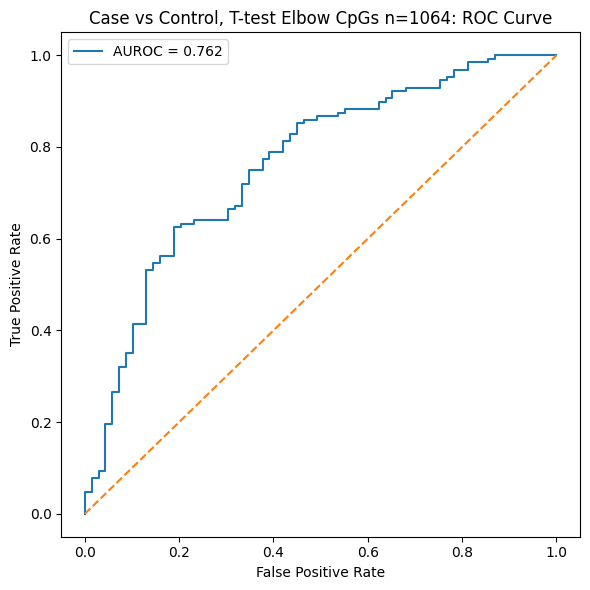

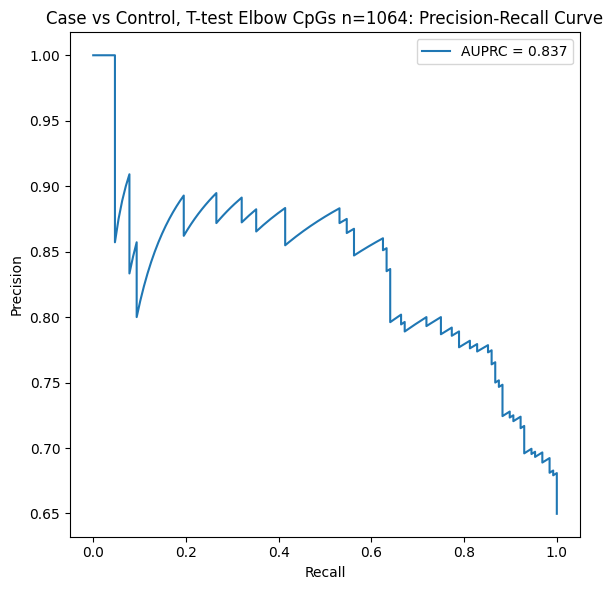

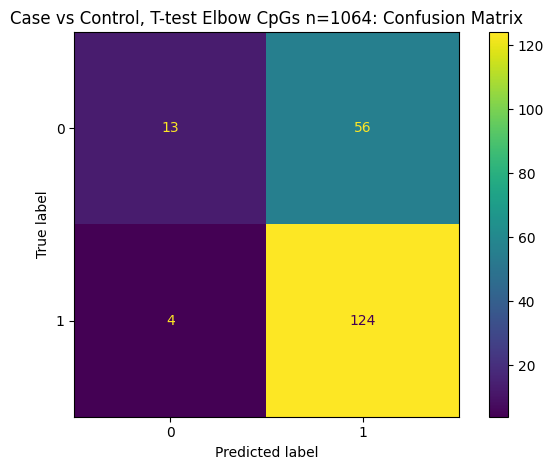

,AUROC,AUPRC,Accuracy,Precision,Recall,F1
0,0.761775,0.836822,0.695431,0.688889,0.96875,0.805195


In [41]:
cc_ttest_metrics = evaluate_binary_model(
    model=ridge_cc_ttest,
    X_test=X_test_cc_ttest_sel,
    y_test=y_test_cc,
    out_prefix=os.path.join(
        cc_out_dir,
        f"case_control_ttest_elbow_{cc_elbow_n}_ridge"
    ),
    plot_title=f"Case vs Control, T-test Elbow CpGs n={cc_elbow_n}"
)

cc_ttest_metrics

#### t-test > rank CpGs > elbow > cutoff at 1064 > regression 

### Cycle phase

In [42]:
print(adata.obs["cycle-phase"].value_counts(dropna=False))

cycle-phase
PE           473
MSE          209
ESE          122
LSE          108
Menstrual     50
SE            22
Name: count, dtype: int64


In [43]:
adata_cp = adata[adata.obs["cycle-phase"].notna()].copy()

y_cp_series = adata_cp.obs["cycle-phase"].map({
    "PE": 0,
    "P": 0,
    "Proliferative": 0,
    "proliferative": 0,
    "ESE": 1,
    "MSE": 1,
    "LSE": 1,
    "SE": 1,
    "Secretory": 1,
    "secretory": 1
})

valid_mask = y_cp_series.notna()

adata_cp = adata_cp[valid_mask].copy()
y_cp = y_cp_series[valid_mask].astype(int).values

X_cp = to_dense(adata_cp.X)
feature_names_cp = adata_cp.var_names.to_numpy()

print("X_cp shape:", X_cp.shape)
print("y_cp shape:", y_cp.shape)
print("Proliferative:", np.sum(y_cp == 0))
print("Secretory:", np.sum(y_cp == 1))

X_cp shape: (934, 759345)
y_cp shape: (934,)
Proliferative: 473
Secretory: 461


In [44]:
X_train_cp, X_test_cp, y_train_cp, y_test_cp = train_test_split(
    X_cp,
    y_cp,
    test_size=0.20,
    random_state=42,
    stratify=y_cp
)

print("X_train_cp:", X_train_cp.shape)
print("X_test_cp:", X_test_cp.shape)
print("Train proliferative:", np.sum(y_train_cp == 0))
print("Train secretory:", np.sum(y_train_cp == 1))
print("Test proliferative:", np.sum(y_test_cp == 0))
print("Test secretory:", np.sum(y_test_cp == 1))

X_train_cp: (747, 759345)
X_test_cp: (187, 759345)
Train proliferative: 378
Train secretory: 369
Test proliferative: 95
Test secretory: 92


In [45]:
cp_ttest_ranked = run_ttest_screening(
    X_train=X_train_cp,
    y_train=y_train_cp,
    feature_names=feature_names_cp,
    out_csv=os.path.join(cp_out_dir, "cycle_phase_ttest_ranked_cpgs.csv")
)

cp_ttest_ranked.head(20)

Group 0 shape: (378, 759345)
Group 1 shape: (369, 759345)


/tmp/ipykernel_5389/3807213857.py:31: RuntimeWarning: divide by zero encountered in log10
  "neg_log10_p": -np.log10(np.clip(p_values, 1e-300, None)),


Saved ranked CpGs to: /mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/cycle_phase/cycle_phase_ttest_ranked_cpgs.csv


,CpG,t_stat,p_value,neg_log10_p,mean_group0,mean_group1,mean_diff_group1_minus_group0,abs_mean_diff
0,cg09521575,15.504063,0.0,inf,2.978679,3.674647,0.695968,0.695968
1,cg25223327,-15.479417,0.0,inf,2.691635,2.187073,-0.504563,0.504563
2,cg26601739,-16.962511,0.0,inf,1.266690,0.930023,-0.336666,0.336666
3,cg08951452,-18.556845,0.0,inf,0.403664,-0.255876,-0.659540,0.659540
4,cg02003565,-15.468990,0.0,inf,1.040516,0.754612,-0.285905,0.285905
5,cg05017003,-16.891567,0.0,inf,0.812433,0.550075,-0.262358,0.262358
6,cg16564333,-17.908306,0.0,inf,2.007437,1.612211,-0.395227,0.395227
7,cg22934449,-18.383549,0.0,inf,3.633214,3.130235,-0.502979,0.502979
8,cg26522002,16.036310,0.0,inf,1.977725,2.575997,0.598273,0.598273
9,cg01433297,-15.618115,0.0,inf,-0.985183,-1.523929,-0.538746,0.538746


In [49]:
# -----------------------------
# How many CpGs pass t-test thresholds
# -----------------------------

pvals = cp_ttest_ranked["p_value"]

print("Total CpGs:", len(pvals))

print("p < 0.05:", (pvals < 0.05).sum())
print("p < 0.01:", (pvals < 0.01).sum())
print("p < 1e-3:", (pvals < 1e-3).sum())
print("p < 1e-5:", (pvals < 1e-5).sum())

Total CpGs: 759345
p < 0.05: 134461
p < 0.01: 61899
p < 1e-3: 24311
p < 1e-5: 7068


In [52]:
from statsmodels.stats.multitest import multipletests

fdr = multipletests(pvals, method="fdr_bh")[1]

print("FDR < 0.05:", (fdr < 0.05).sum())

FDR < 0.05: 32386


In [53]:
# -----------------------------
# FDR-based CpG selection for cycle phase
# -----------------------------

from statsmodels.stats.multitest import multipletests

pvals_cp = cp_ttest_ranked["p_value"].values

_, cp_fdr_vals, _, _ = multipletests(
    pvals_cp,
    alpha=0.05,
    method="fdr_bh"
)

cp_ttest_ranked["FDR"] = cp_fdr_vals

cp_fdr_selected_cpgs = cp_ttest_ranked.loc[
    cp_ttest_ranked["FDR"] < 0.05,
    "CpG"
].values

cp_fdr_n = len(cp_fdr_selected_cpgs)

print("Cycle phase FDR-selected CpGs:", cp_fdr_n)

Cycle phase FDR-selected CpGs: 32386


In [54]:
# -----------------------------
# Subset train/test to FDR-selected CpGs
# -----------------------------

cpg_to_idx_cp = {cpg: i for i, cpg in enumerate(feature_names_cp)}

selected_idx_cp = [cpg_to_idx_cp[cpg] for cpg in cp_fdr_selected_cpgs]

X_train_cp_fdr_sel = X_train_cp[:, selected_idx_cp]
X_test_cp_fdr_sel = X_test_cp[:, selected_idx_cp]

print("X_train_cp_fdr_sel:", X_train_cp_fdr_sel.shape)
print("X_test_cp_fdr_sel:", X_test_cp_fdr_sel.shape)

X_train_cp_fdr_sel: (747, 32386)
X_test_cp_fdr_sel: (187, 32386)


In [55]:
# -----------------------------
# Train ridge model using FDR-selected CpGs
# -----------------------------

ridge_cp_fdr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        C=0.000215,
        solver="lbfgs",
        max_iter=5000
    ))
])

ridge_cp_fdr.fit(X_train_cp_fdr_sel, y_train_cp)

print("Finished training cycle phase ridge model using FDR-selected CpGs.")

Finished training cycle phase ridge model using FDR-selected CpGs.


Saved metrics to: /mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/cycle_phase/cycle_phase_fdr_32386_ridge_metrics.csv


,AUROC,AUPRC,Accuracy,Precision,Recall,F1
0,0.977346,0.980442,0.925134,0.953488,0.891304,0.921348


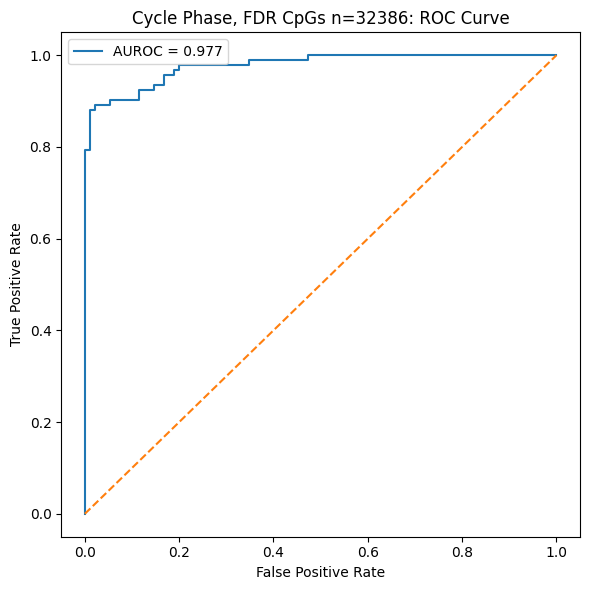

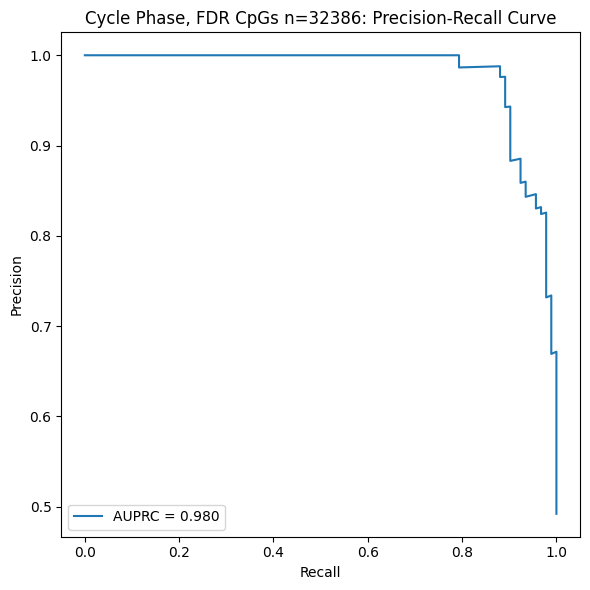

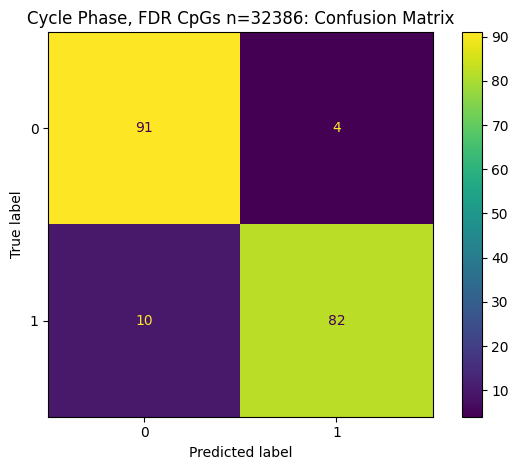

,AUROC,AUPRC,Accuracy,Precision,Recall,F1
0,0.977346,0.980442,0.925134,0.953488,0.891304,0.921348


In [56]:
# -----------------------------
# Evaluate FDR-selected cycle phase model
# -----------------------------

cp_fdr_metrics = evaluate_binary_model(
    model=ridge_cp_fdr,
    X_test=X_test_cp_fdr_sel,
    y_test=y_test_cp,
    out_prefix=os.path.join(
        cp_out_dir,
        f"cycle_phase_fdr_{cp_fdr_n}_ridge"
    ),
    plot_title=f"Cycle Phase, FDR CpGs n={cp_fdr_n}"
)

cp_fdr_metrics

In [58]:
# -----------------------------
# Combine metrics (robust version)
# -----------------------------

cc_label = f"T-test elbow n={cc_ttest_elbow_n}" if 'cc_ttest_elbow_n' in globals() else "T-test elbow"

cc_ttest_metrics_labeled = cc_ttest_metrics.copy()
cc_ttest_metrics_labeled.insert(0, "Outcome", "Case vs Control")
cc_ttest_metrics_labeled.insert(1, "Feature_Selection", cc_label)

cp_fdr_metrics_labeled = cp_fdr_metrics.copy()
cp_fdr_metrics_labeled.insert(0, "Outcome", "Cycle Phase")
cp_fdr_metrics_labeled.insert(1, "Feature_Selection", f"T-test FDR < 0.05 n={cp_fdr_n}")

ttest_combined_metrics = pd.concat(
    [cc_ttest_metrics_labeled, cp_fdr_metrics_labeled],
    ignore_index=True
)

ttest_combined_metrics_path = os.path.join(out_dir, "ttest_fdr_ridge_combined_metrics.csv")
ttest_combined_metrics.to_csv(ttest_combined_metrics_path, index=False)

print("Saved combined metrics to:", ttest_combined_metrics_path)
ttest_combined_metrics

Saved combined metrics to: /mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/ttest_fdr_ridge_combined_metrics.csv


,Outcome,Feature_Selection,AUROC,AUPRC,Accuracy,Precision,Recall,F1
0,Case vs Control,T-test elbow,0.761775,0.836822,0.695431,0.688889,0.968750,0.805195
1,Cycle Phase,T-test FDR < 0.05 n=32386,0.977346,0.980442,0.925134,0.953488,0.891304,0.921348


#### ran t-tests on all CpGs in the training set, ranked them by significance, selected the top ones, and used those to train and evaluate a ridge model on unseen test data, found an elbow for case vs control but not for cycle phase (so we used the entire t-test FDR set of features which was around 32k) 

## univariate logistic regression 

In [66]:
import statsmodels.api as sm
from statsmodels.tools.sm_exceptions import PerfectSeparationError

In [67]:
def run_univariate_logistic_screening(X_train, y_train, feature_names, out_csv=None):
    """
    Runs one logistic regression per CpG using training data only.
    Assumes y_train is binary: 0 vs 1.
    """

    results = []

    for i, cpg in enumerate(feature_names):
        x_i = X_train[:, i]

        try:
            X_design = sm.add_constant(x_i)
            model = sm.Logit(y_train, X_design)
            fit = model.fit(disp=0)

            coef = fit.params[1]
            p_value = fit.pvalues[1]

            results.append({
                "CpG": cpg,
                "coef": coef,
                "abs_coef": abs(coef),
                "p_value": p_value,
                "neg_log10_p": -np.log10(np.clip(p_value, 1e-300, None))
            })

        except (PerfectSeparationError, np.linalg.LinAlgError, ValueError):
            results.append({
                "CpG": cpg,
                "coef": np.nan,
                "abs_coef": np.nan,
                "p_value": np.nan,
                "neg_log10_p": np.nan
            })

        if (i + 1) % 10000 == 0:
            print(f"Processed {i + 1} / {len(feature_names)} CpGs")

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        "p_value",
        ascending=True,
        na_position="last"
    ).reset_index(drop=True)

    if out_csv is not None:
        results_df.to_csv(out_csv, index=False)
        print("Saved univariate regression results to:", out_csv)

    return results_df

In [68]:
cc_uni_out_dir = os.path.join(out_dir, "case_control_univariate_logistic")
os.makedirs(cc_uni_out_dir, exist_ok=True)

print(cc_uni_out_dir)

/mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/case_control_univariate_logistic


In [69]:
cc_uni_out_dir = os.path.join(out_dir, "case_control_univariate_logistic")
os.makedirs(cc_uni_out_dir, exist_ok=True)

print(cc_uni_out_dir)

/mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/case_control_univariate_logistic


In [70]:
cc_uni_ranked = run_univariate_logistic_screening(
    X_train=X_train_cc,
    y_train=y_train_cc,
    feature_names=feature_names_cc,
    out_csv=os.path.join(
        cc_uni_out_dir,
        "case_control_univariate_logistic_ranked_cpgs.csv"
    )
)

cc_uni_ranked.head(20)

Processed 10000 / 759345 CpGs
Processed 20000 / 759345 CpGs
Processed 30000 / 759345 CpGs
Processed 40000 / 759345 CpGs
Processed 50000 / 759345 CpGs
Processed 60000 / 759345 CpGs
Processed 70000 / 759345 CpGs
Processed 80000 / 759345 CpGs
Processed 90000 / 759345 CpGs
Processed 100000 / 759345 CpGs
Processed 110000 / 759345 CpGs
Processed 120000 / 759345 CpGs
Processed 130000 / 759345 CpGs
Processed 140000 / 759345 CpGs
Processed 150000 / 759345 CpGs
Processed 160000 / 759345 CpGs
Processed 170000 / 759345 CpGs
Processed 180000 / 759345 CpGs
Processed 190000 / 759345 CpGs
Processed 200000 / 759345 CpGs
Processed 210000 / 759345 CpGs
Processed 220000 / 759345 CpGs
Processed 230000 / 759345 CpGs
Processed 240000 / 759345 CpGs
Processed 250000 / 759345 CpGs
Processed 260000 / 759345 CpGs
Processed 270000 / 759345 CpGs
Processed 280000 / 759345 CpGs
Processed 290000 / 759345 CpGs
Processed 300000 / 759345 CpGs
Processed 310000 / 759345 CpGs
Processed 320000 / 759345 CpGs
Processed 330000 

,CpG,coef,abs_coef,p_value,neg_log10_p
0,cg09976716,0.712881,0.712881,7.862878e-07,6.104418
1,cg04415176,0.391757,0.391757,1.526674e-06,5.816254
2,cg05587394,0.737426,0.737426,1.588030e-06,5.799141
3,cg11136960,0.917018,0.917018,1.980369e-06,5.703254
4,cg02177811,1.409779,1.409779,2.388464e-06,5.621881
5,cg18188952,-1.239472,1.239472,2.748312e-06,5.560934
6,cg07706375,2.515554,2.515554,3.253576e-06,5.487639
7,cg25044850,1.444902,1.444902,3.369904e-06,5.472382
8,cg21974239,-0.976720,0.976720,3.847697e-06,5.414799
9,cg25856265,-1.294446,1.294446,4.007525e-06,5.397124


In [71]:
from statsmodels.stats.multitest import multipletests

# Add FDR correction to ranked univariate results
valid_pvals = cc_uni_ranked["p_value"].notna()

cc_uni_ranked["fdr_bh"] = np.nan
cc_uni_ranked.loc[valid_pvals, "fdr_bh"] = multipletests(
    cc_uni_ranked.loc[valid_pvals, "p_value"],
    method="fdr_bh"
)[1]

# Select all FDR-significant CpGs
fdr_threshold = 0.05

cc_uni_selected_cpgs = cc_uni_ranked.loc[
    cc_uni_ranked["fdr_bh"] < fdr_threshold,
    "CpG"
].tolist()

cc_uni_selected_path = os.path.join(
    cc_uni_out_dir,
    f"case_control_fdr_{fdr_threshold}_univariate_logistic_cpgs.csv"
)

pd.Series(cc_uni_selected_cpgs, name="CpG").to_csv(cc_uni_selected_path, index=False)

# Also save updated ranked table with FDR column
cc_uni_ranked.to_csv(
    os.path.join(cc_uni_out_dir, "case_control_univariate_logistic_ranked_cpgs_with_fdr.csv"),
    index=False
)

print("FDR threshold:", fdr_threshold)
print("Selected CpGs:", len(cc_uni_selected_cpgs))
print("Saved selected CpGs to:", cc_uni_selected_path)

FDR threshold: 0.05
Selected CpGs: 0
Saved selected CpGs to: /mnt/efs/home/ubuntu/endo-me_data/ttest_feature_selection_outputs/case_control_univariate_logistic/case_control_fdr_0.05_univariate_logistic_cpgs.csv


In [72]:
selected_idx_cc_uni = [cpg_to_idx_cc[cpg] for cpg in cc_uni_selected_cpgs]

X_train_cc_uni_sel = X_train_cc[:, selected_idx_cc_uni]
X_test_cc_uni_sel = X_test_cc[:, selected_idx_cc_uni]

print("X_train_cc_uni_sel:", X_train_cc_uni_sel.shape)
print("X_test_cc_uni_sel:", X_test_cc_uni_sel.shape)

X_train_cc_uni_sel: (787, 0)
X_test_cc_uni_sel: (197, 0)


In [73]:
ridge_cc_uni = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        C=0.000215,
        solver="lbfgs",
        max_iter=5000
    ))
])

ridge_cc_uni.fit(X_train_cc_uni_sel, y_train_cc)

print("Finished training case/control ridge model using univariate-selected CpGs.")

ValueError: Found array with 0 feature(s) (shape=(787, 0)) while a minimum of 1 is required by StandardScaler.

In [ ]:
cc_uni_metrics = evaluate_binary_model(
    model=ridge_cc_uni,
    X_test=X_test_cc_uni_sel,
    y_test=y_test_cc,
    out_prefix=os.path.join(cc_uni_out_dir, f"case_control_top_{top_n_cc_uni}_univariate_logistic_ridge"),
    plot_title=f"Case vs Control, Top {top_n_cc_uni} Univariate Logistic CpGs"
)

cc_uni_metrics

In [ ]:
cp_uni_out_dir = os.path.join(out_dir, "cycle_phase_univariate_logistic")
os.makedirs(cp_uni_out_dir, exist_ok=True)

print(cp_uni_out_dir)

In [ ]:
cp_uni_ranked = run_univariate_logistic_screening(
    X_train=X_train_cp,
    y_train=y_train_cp,
    feature_names=feature_names_cp,
    out_csv=os.path.join(cp_uni_out_dir, "cycle_phase_univariate_logistic_ranked_cpgs.csv")
)

cp_uni_ranked.head(20)

In [ ]:
top_n_cp_uni = 1000

cp_uni_selected_cpgs = cp_uni_ranked["CpG"].dropna().iloc[:top_n_cp_uni].tolist()

cp_uni_selected_path = os.path.join(
    cp_uni_out_dir,
    f"cycle_phase_top_{top_n_cp_uni}_univariate_logistic_cpgs.csv"
)

pd.Series(cp_uni_selected_cpgs, name="CpG").to_csv(cp_uni_selected_path, index=False)

print("Selected CpGs:", len(cp_uni_selected_cpgs))
print("Saved selected CpGs to:", cp_uni_selected_path)

In [ ]:
selected_idx_cp_uni = [cpg_to_idx_cp[cpg] for cpg in cp_uni_selected_cpgs]

X_train_cp_uni_sel = X_train_cp[:, selected_idx_cp_uni]
X_test_cp_uni_sel = X_test_cp[:, selected_idx_cp_uni]

print("X_train_cp_uni_sel:", X_train_cp_uni_sel.shape)
print("X_test_cp_uni_sel:", X_test_cp_uni_sel.shape)

In [ ]:
ridge_cp_uni = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        C=0.000215,
        solver="lbfgs",
        max_iter=5000
    ))
])

ridge_cp_uni.fit(X_train_cp_uni_sel, y_train_cp)

print("Finished training cycle phase ridge model using univariate-selected CpGs.")

In [ ]:
cp_uni_metrics = evaluate_binary_model(
    model=ridge_cp_uni,
    X_test=X_test_cp_uni_sel,
    y_test=y_test_cp,
    out_prefix=os.path.join(cp_uni_out_dir, f"cycle_phase_top_{top_n_cp_uni}_univariate_logistic_ridge"),
    plot_title=f"Cycle Phase, Top {top_n_cp_uni} Univariate Logistic CpGs"
)

cp_uni_metrics

In [ ]:
comparison_rows = []

cc_ttest_row = cc_metrics.copy()
cc_ttest_row.insert(0, "Outcome", "Case vs Control")
cc_ttest_row.insert(1, "Feature_Selection", f"T-test top {top_n_cc}")
comparison_rows.append(cc_ttest_row)

cc_uni_row = cc_uni_metrics.copy()
cc_uni_row.insert(0, "Outcome", "Case vs Control")
cc_uni_row.insert(1, "Feature_Selection", f"Univariate logistic top {top_n_cc_uni}")
comparison_rows.append(cc_uni_row)

cp_ttest_row = cp_metrics.copy()
cp_ttest_row.insert(0, "Outcome", "Cycle Phase")
cp_ttest_row.insert(1, "Feature_Selection", f"T-test top {top_n_cp}")
comparison_rows.append(cp_ttest_row)

cp_uni_row = cp_uni_metrics.copy()
cp_uni_row.insert(0, "Outcome", "Cycle Phase")
cp_uni_row.insert(1, "Feature_Selection", f"Univariate logistic top {top_n_cp_uni}")
comparison_rows.append(cp_uni_row)

method_comparison = pd.concat(comparison_rows, ignore_index=True)

comparison_path = os.path.join(out_dir, "ttest_vs_univariate_logistic_ridge_metrics.csv")
method_comparison.to_csv(comparison_path, index=False)

print("Saved comparison table to:", comparison_path)
method_comparison